<h1>Train — AlexNet</h1>

Trains and evaluates AlexNet **from scratch (no ImageNet pretraining)** using the hand-picked hyperparameters from `ARCH_HYPERPARAMS["alexnet"]`, then saves its results and weights to disk for the results notebook. Unlike every other architecture here, this one starts from random weights instead of a pretrained backbone -- included to see how a small CNN trained from scratch on this dataset compares to the transfer-learning models.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1707 | Val: 415 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["alexnet"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"AlexNet: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

AlexNet: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (AlexNet, trained from scratch -- no pretrained weights)
# ---------------------------------------------------------
model = models.alexnet(weights=None)  # no ImageNet pretraining, unlike every other architecture here

# AlexNet's classifier is nn.Sequential(Dropout, Linear, ReLU, Dropout, Linear,
# ReLU, Linear) — swap out just the final Linear layer (index 6) for our
# (optionally deeper) classifier head, same as the fc/classifier swaps used
# for the other architectures.
in_f = model.classifier[6].in_features
model.classifier[6] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[AlexNet] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[AlexNet] Epoch   1/100 | LR: 1.00e-04 | train loss 1.3591 acc 0.384 | val loss 1.1638 acc 0.465 *


[AlexNet] Epoch   2/100 | LR: 1.00e-04 | train loss 1.2476 acc 0.442 | val loss 0.9833 acc 0.482 *


[AlexNet] Epoch   3/100 | LR: 1.00e-04 | train loss 1.1474 acc 0.484 | val loss 0.9960 acc 0.545


[AlexNet] Epoch   4/100 | LR: 1.00e-04 | train loss 1.0611 acc 0.517 | val loss 0.8483 acc 0.593 *


...

[AlexNet] Epoch  96/100 | LR: 1.00e-10 | train loss 0.5008 acc 0.751 | val loss 0.5960 acc 0.771


[AlexNet] Epoch  97/100 | LR: 1.00e-10 | train loss 0.5076 acc 0.753 | val loss 0.5960 acc 0.771


[AlexNet] Epoch  98/100 | LR: 1.00e-10 | train loss 0.4956 acc 0.754 | val loss 0.5960 acc 0.771


[AlexNet] Epoch  99/100 | LR: 1.00e-10 | train loss 0.5033 acc 0.751 | val loss 0.5960 acc 0.771


[AlexNet] Epoch 100/100 | LR: 1.00e-10 | train loss 0.5062 acc 0.758 | val loss 0.5960 acc 0.771

[AlexNet] Restored best checkpoint (val loss = 0.5605)


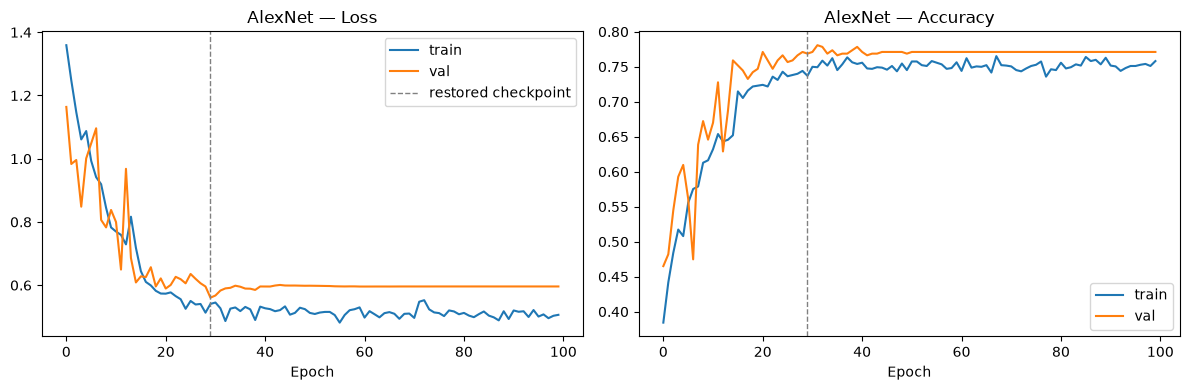

In [4]:
# No early stopping (patience=None): from random init AlexNet can sit on a
# ~ln(4) loss plateau for many epochs before it starts learning, and noisy
# val loss during that plateau made early stopping quit too soon.
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, None, "AlexNet", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "AlexNet")

## Evaluate on the test set

[AlexNet] Test accuracy: 0.780


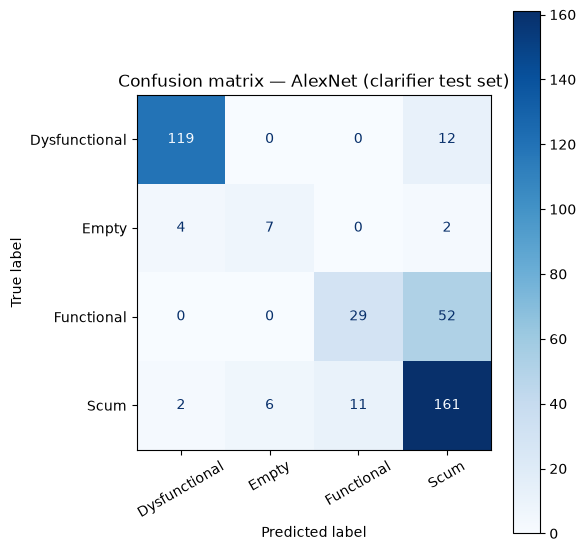

               precision    recall  f1-score   support

Dysfunctional      0.952     0.908     0.930       131
        Empty      0.538     0.538     0.538        13
   Functional      0.725     0.358     0.479        81
         Scum      0.709     0.894     0.791       180

     accuracy                          0.780       405
    macro avg      0.731     0.675     0.685       405
 weighted avg      0.785     0.780     0.765       405



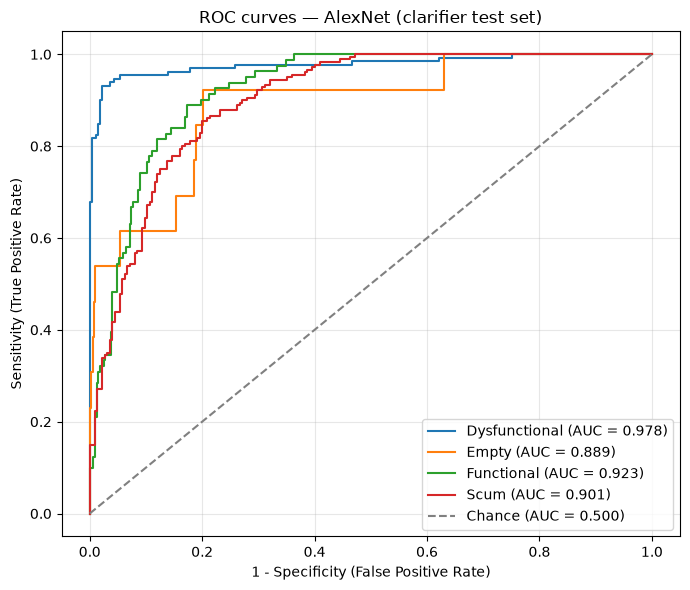

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.978
  Empty          : 0.889
  Functional     : 0.923
  Scum           : 0.901

Mean AUC (over 4/4 classes with test examples): 0.923


(np.float64(0.7802469135802469),
 {'Dysfunctional': 0.9779628907338273,
  'Empty': 0.8893249607535322,
  'Functional': 0.9228014022252704,
  'Scum': 0.9011358024691358})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "AlexNet", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("AlexNet", "alexnet")

Saved results to ../results/clarifier_aug/results_clarifier_alexnet_NoordelikeWerke.pkl


Saved model weights to ../models/clarifier_alexnet_cnn.pt
